In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from pysuto.util import get_path

figp = r'/mnt/nfs_fineprint/tmp/PYSUT/pySUTO/figs/ex'

# Region identification for model ~30

In [3]:
p=r'/mnt/nfs_fineprint/tmp/PYSUT/pySUTO/data/proc/datafeed/icsg_clean/icsg_flows.csv'

f = pd.read_csv(p)
f

,Region,Type,Year,Value,Process,Supply_Use,Unit,Year_loaded_from_file
0,Indonesia,Concentrates,1998,809.2000,Mining,Supply,kt,2005
1,Iran,Concentrates,1998,118.8000,Mining,Supply,kt,2005
2,Japan,Concentrates,1998,1.1000,Mining,Supply,kt,2005
3,Kazakhstan,Concentrates,1998,338.6000,Mining,Supply,kt,2005
4,North Macedonia,Concentrates,1998,9.1000,Mining,Supply,kt,2005
...,...,...,...,...,...,...,...,...
7155,Italy,Copper Alloy,2022,681.8999,Semi,Supply,kt,2025
7156,Japan,Copper,2022,970.0000,Semi,Supply,kt,2025
7157,Japan,Copper Alloy,2022,342.0000,Semi,Supply,kt,2025
7158,South Korea,Copper,2022,638.6460,Semi,Supply,kt,2025


In [21]:
# df = your dataframe

# Step 1: get top 30 regions per Type based on Value
top30_per_type = (
    f.sort_values('Value', ascending=False)
      .groupby(['Type', 'Year'])
      .head(10)
)

# Step 2: get unique regions from these selections
unique_regions = top30_per_type['Region'].unique()

# Optional: convert to list
unique_regions_list = list(unique_regions)

stock_regions = ['United States', 'Chile', 'China', 'Germany', 'Japan', 'Taiwan', 'Singapore', 'Malaysia', 'South Korea', 'Spain', 'Iran', 'Belgium', 'Netherlands', 'United Arab Emirates', 'France', 'Brazil', 'United Kingdom', 'Sweden', 'Italy', 'Poland', 'Zambia', 'Canada', 'Peru', 'South Africa', 'Australia', 'Philippines', 'Scandinavia', 'India', 'Bulgaria', 'Slovakia', 'Greece']

# combine and deduplicate
combined_regions = set(unique_regions_list) | set(stock_regions)
# convert back to sorted list
final_regions = sorted(combined_regions)
final_regions
len(final_regions)

46

In [24]:
print(final_regions)

['Argentina', 'Australia', 'Austria', 'Belgium', 'Belgium-Luxembourg', 'Botswana', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'Congo, D.R.', 'France', 'Germany', 'Greece', 'India', 'Indonesia', 'Iran', 'Italy', 'Japan', 'Kazakhstan', 'Luxembourg', 'Malaysia', 'Mauritania', 'Mexico', 'Netherlands', 'Papua New Guinea', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Russia', 'Scandinavia', 'Singapore', 'Slovakia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Taiwan', 'United Arab Emirates', 'United Kingdom', 'United States', 'Uzbekistan', 'Zambia']


In [18]:
len(f.Region.unique(
    
))

87

In [28]:
print(sorted(f.Region.unique()))


['Albania', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Belgium', 'Belgium-Luxembourg', 'Bolivia', 'Botswana', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia', 'Congo Rep.', 'Congo, D.R.', 'Croatia', 'Cuba', 'Cyprus', 'Czech Rep.', 'Denmark', 'Dominican Rep.', 'Ecuador', 'Egypt', 'Eritrea', 'Finland', 'France', 'Georgia', 'Germany', 'Greece', 'Honduras', 'Hungary', 'India', 'Indonesia', 'Iran', 'Italy', 'Japan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Luxembourg', 'Malaysia', 'Mauritania', 'Mexico', 'Mongolia', 'Morocco', 'Myanmar', 'Namibia', 'Netherlands', 'New Zealand', 'North Korea', 'North Macedonia', 'Norway', 'Oman', 'Pakistan', 'Panama', 'Papua New Guinea', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Romania', 'Russia', 'Saudi Arabia', 'Scandinavia', 'Serbia', 'Serbia and Montenegro', 'Singapore', 'Slovakia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Ukraine', 'United Arab Emirates', 'United Kingdom', '

# Mining

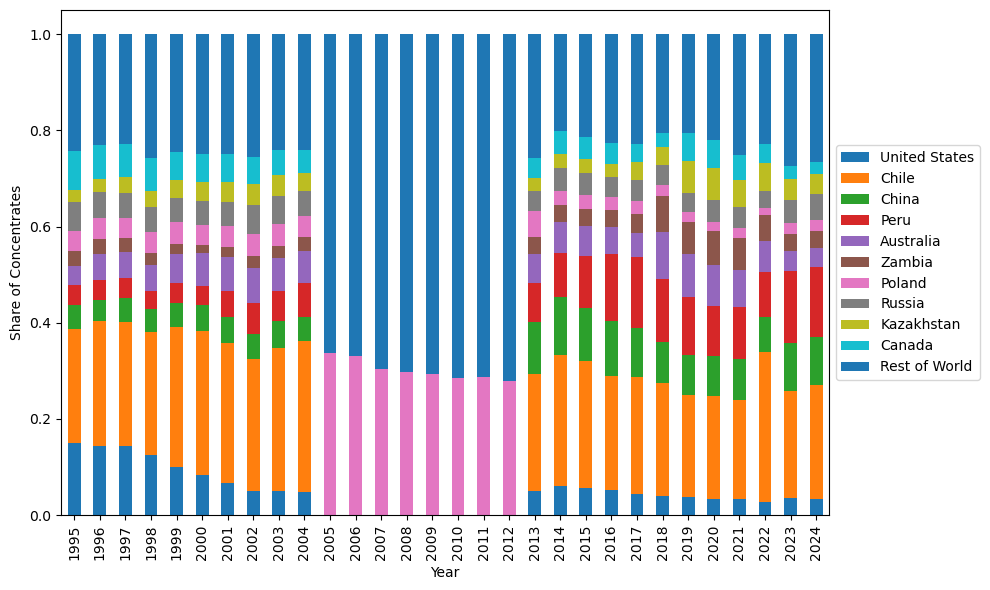

In [39]:
# -------------------------------------------------
# 1. Filter dataset
# -------------------------------------------------

d = f[f['Type'] == 'Concentrates'].copy()

#top 5 regions

c_select = ['United States', 'Chile', 'China', 'Peru', 'Australia', 'Congo, D.R.'
            'Argentina', 'Zambia', 'Poland', 'Russia' ,'Kazakhstan', 'Canada']

# aggregate country values
data = d.groupby(['Year','Region'])['Value'].sum().reset_index()

# total per year
total = data.groupby('Year')['Value'].sum().reset_index()
total = total.rename(columns={'Value':'Total'})

data = data.merge(total, on='Year')

# compute shares
data['Share'] = data['Value'] / data['Total']

# -------------------------------------------------
# 2. Label Rest of World
# -------------------------------------------------

data['Region_plot'] = data['Region'].where(
    data['Region'].isin(c_select),
    'Rest of World'
)

data = data.groupby(['Year','Region_plot'])['Share'].sum().reset_index()

# -------------------------------------------------
# 3. Pivot
# -------------------------------------------------

df_plot = data.pivot(index='Year', columns='Region_plot', values='Share').fillna(0)

order = c_select + ['Rest of World']
df_plot = df_plot[[c for c in order if c in df_plot.columns]]

# -------------------------------------------------
# 4. Plot
# -------------------------------------------------

ax = df_plot.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    edgecolor='none'
)

ax.set_ylabel('Share of Concentrates')
ax.set_xlabel('Year')

plt.legend(loc='center left', bbox_to_anchor=(1,0.5))

plt.tight_layout()
plt.show()

In [37]:
d[d.Year == 2021]

,Region,Type,Year,Value,Process,Supply_Use,Unit,Year_loaded_from_file
4127,Australia,Concentrates,2021,778.032031,Mining,Supply,kt,2023
4128,Canada,Concentrates,2021,547.807286,Mining,Supply,kt,2023
4132,Saudi Arabia,Concentrates,2021,75.939000,Mining,Supply,kt,2023
4133,Mexico,Concentrates,2021,602.440000,Mining,Supply,kt,2023
4134,Morocco,Concentrates,2021,31.362000,Mining,Supply,kt,2023
4135,Georgia,Concentrates,2021,7.002000,Mining,Supply,kt,2023
4136,Kazakhstan,Concentrates,2021,595.391000,Mining,Supply,kt,2023
4143,Serbia,Concentrates,2021,120.920000,Mining,Supply,kt,2023
4144,Zambia,Concentrates,2021,702.807000,Mining,Supply,kt,2023
4984,Bolivia,Concentrates,2021,1.601000,Mining,Supply,kt,2025
